**Student Name :** LENKA RAJESH  
**Roll number  :** 23341A05E7

# Image Segmentation System — Pixel-Level Foreground/Background Separation
### Using a Pre-trained (U²-Net) Model.

**Project Title:** Image Segmentation System
**Problem Statement:** Separate foreground objects from background at pixel level.
**Suggested Pre-trained Model:** U-Net



## 1. Problem Statement & Objective

**Problem:** Given any image, automatically identify which pixels belong to the main
(foreground) object vs the background — a pixel-level mask, not just a box.

**Why it matters:** Used in background removal (e-commerce, video calls), photo
editing, and as a building block for scene understanding.

**Expected output:** For every test image → (1) a black/white **segmentation mask**,
(2) the **foreground cut out** from the background.

**Objective:** Load an already-trained model and use it only for **inference**
(no training from scratch):

`Input Image → Pre-processing → Pre-trained Model → Inference → Post-processing → Output`


## 2. About the Pre-trained Model

 A plain U-Net has no single universal pretrained
checkpoint for general foreground/background separation (it's normally trained per
dataset).we use
**U²-Net** — a model built on the same encoder–decoder + skip-connection idea as U-Net,
with real pretrained weights released specifically for
Salient Object Detection.

| | |
|---|---|
| **Model** | U²-Net (nested U-Net structure) |
| **Trained on** | DUTS-TR salient object detection dataset |
| **Source** | github.com/xuebinqin/U-2-Net |
| **Loaded via** | `rembg` library (MIT license) |
| **Input** | RGB image, any size |
| **Output** | Per-pixel foreground probability mask (0–255) |

**Working principle:** Encoder compresses the image (learns "what"), decoder expands
it back to full resolution (reconstructs "where"), and **skip connections** carry fine
spatial detail from encoder to decoder so mask edges stay sharp. Output is passed
through a sigmoid → one probability per pixel → thresholded into a mask.

**Why RGB and not grayscale?** Color is often the strongest signal separating an
object from its background (e.g. a red apple vs green leaves would look almost
identical in grayscale). The model's first layer is also literally built for 3 input
channels because it was trained on RGB — feeding grayscale would break the input shape
or discard the color cues the model relies on.


## 3. Installation

Google Colab already has `numpy`, `opencv`, `pillow`, `rembg`,`matplotlib`, and
`scikit-image` pre-installed and working correctly.
.



In [1]:
import numpy as np
import scipy

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)

NumPy: 2.5.3
SciPy: 1.18.1


In [2]:
from rembg import remove, new_session

print("rembg imported successfully")

c:\Users\lraje\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


rembg imported successfully


## 4. Importing Libraries
os - for file directories  
numpy - for numerical calculations  
matplotlib - for visualizing the image  
PIL - to load the sample images  
rembg - library   that provides the convinient interface for the pre-trained model  
remove - removes the background (resize/transforms the image internally)  
new_session - create a session with the model mentioned

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data as sample_data
from rembg import remove, new_session

print("Libraries imported successfully")

Libraries imported successfully


## 5. Loading the Pre-trained Model
loads the official pretrained
U²-Net weights. Only loading happens here — no training.


In [4]:
model_session = new_session("u2net")
print("Pre-trained U2-Net model loaded successfully")

100%|########################################| 176M/176M [00:00<00:00, 172GB/s]


Pre-trained U2-Net model loaded successfully


## 6. Preparing 3 Test Images

AS the inputs we can use **3 methods** -->  
**1.sample images from scikit-image** (already installed in Colab): a person, a cat, and a coffee cup — each with a clear foreground subject  

**2. Upload the images from the local machine** where a window pops and have an upload button to upload the images.  

**3. Upload the image url's from the internet** where we paste the images address from the internet.

**Want to choose your own method instead?** Uncomment the appropriate lines in the  cell.


In [5]:

import os
os.makedirs("test_images", exist_ok=True)

# ------------------------------------------------------------
# METHOD 1: Built-in sample images (no upload/internet needed)

# from skimage import data as sample_data
# from PIL import Image

# sample_images = {
#     "test_images/test1_person.jpg": sample_data.astronaut(),
#     "test_images/test2_cat.jpg": sample_data.chelsea(),
#     "test_images/test3_coffee.jpg": sample_data.coffee(),
# }
# for path, arr in sample_images.items():
#     Image.fromarray(arr).save(path)

# test_image_paths = list(sample_images.keys())

# ------------------------------------------------------------
# METHOD 2: Upload your own images from your computer

# from google.colab import files
# uploaded = files.upload()          # a "Choose Files" button will appear
# test_image_paths = list(uploaded.keys())

# ------------------------------------------------------------
# METHOD 3: Download images directly from the internet

import requests
image_urls = [
    "https://w0.peakpx.com/wallpaper/320/168/HD-wallpaper-pawan-kalyan-actor-bheemla-nayak-pavan-kalyan-pawankalyan-telugu-movies-bollywood-movies-pavan.jpg",
    "https://images.pexels.com/photos/35671096/pexels-photo-35671096.jpeg?cs=srgb&dl=pexels-sabik-nisam-854249800-35671096.jpg&fm=jpg",
    "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSU4uTdJcrWpkg1-j0QF-ejf5roAnCVun8CoGupinWM93TTdUdKWhfZsSjw&s=10",
]
test_image_paths = []
for i, url in enumerate(image_urls, start=1):
    path = f"test_images/internet_test{i}.jpg"
    response = requests.get(url, timeout=10)
    with open(path, "wb") as f:
        f.write(response.content)
    test_image_paths.append(path)

print("Test images ready:")
for p in test_image_paths:
    print(" -", p)

Test images ready:
 - test_images/internet_test1.jpg
 - test_images/internet_test2.jpg
 - test_images/internet_test3.jpg


## 7. The Segmentation Pipeline (Pre-processing → Inference → Post-processing)

One simple function does the full pipeline for one image:
1. **Pre-processing:** open the image and make sure it's RGB.
2. **Inference:** pass it to the pretrained model (`remove`), which internally resizes
   + normalizes, then runs a forward pass only.
3. **Post-processing:** read the mask from the alpha channel, make it strictly
   black/white, and build a foreground-on-white-background image.


In [6]:
def segment_image(path, session, threshold=128):
    """Run the full pipeline on one image and return original, mask, and foreground."""
    # 1) Pre-processing
    original = Image.open(path).convert("RGB")

    # 2) Inference (forward pass through the pretrained model only)
    result_rgba = remove(original, session=session)      # returns RGBA image
    mask = np.array(result_rgba.split()[-1])              # alpha channel = predicted mask

    # 3) Post-processing
    binary_mask = (mask > threshold).astype(np.uint8) * 255
    mask_3ch = np.dstack([binary_mask] * 3) / 255.0
    original_np = np.array(original)
    white_bg = np.ones_like(original_np) * 255
    foreground = (original_np * mask_3ch + white_bg * (1 - mask_3ch)).astype(np.uint8)

    return original, binary_mask, foreground

print("Pipeline function ready")

Pipeline function ready


## 8. Running on All 3 Test Cases + Visualization

This satisfies the assignment's "at least 3 test cases" requirement.


Processed: test_images/internet_test1.jpg
Processed: test_images/internet_test2.jpg
Processed: test_images/internet_test3.jpg


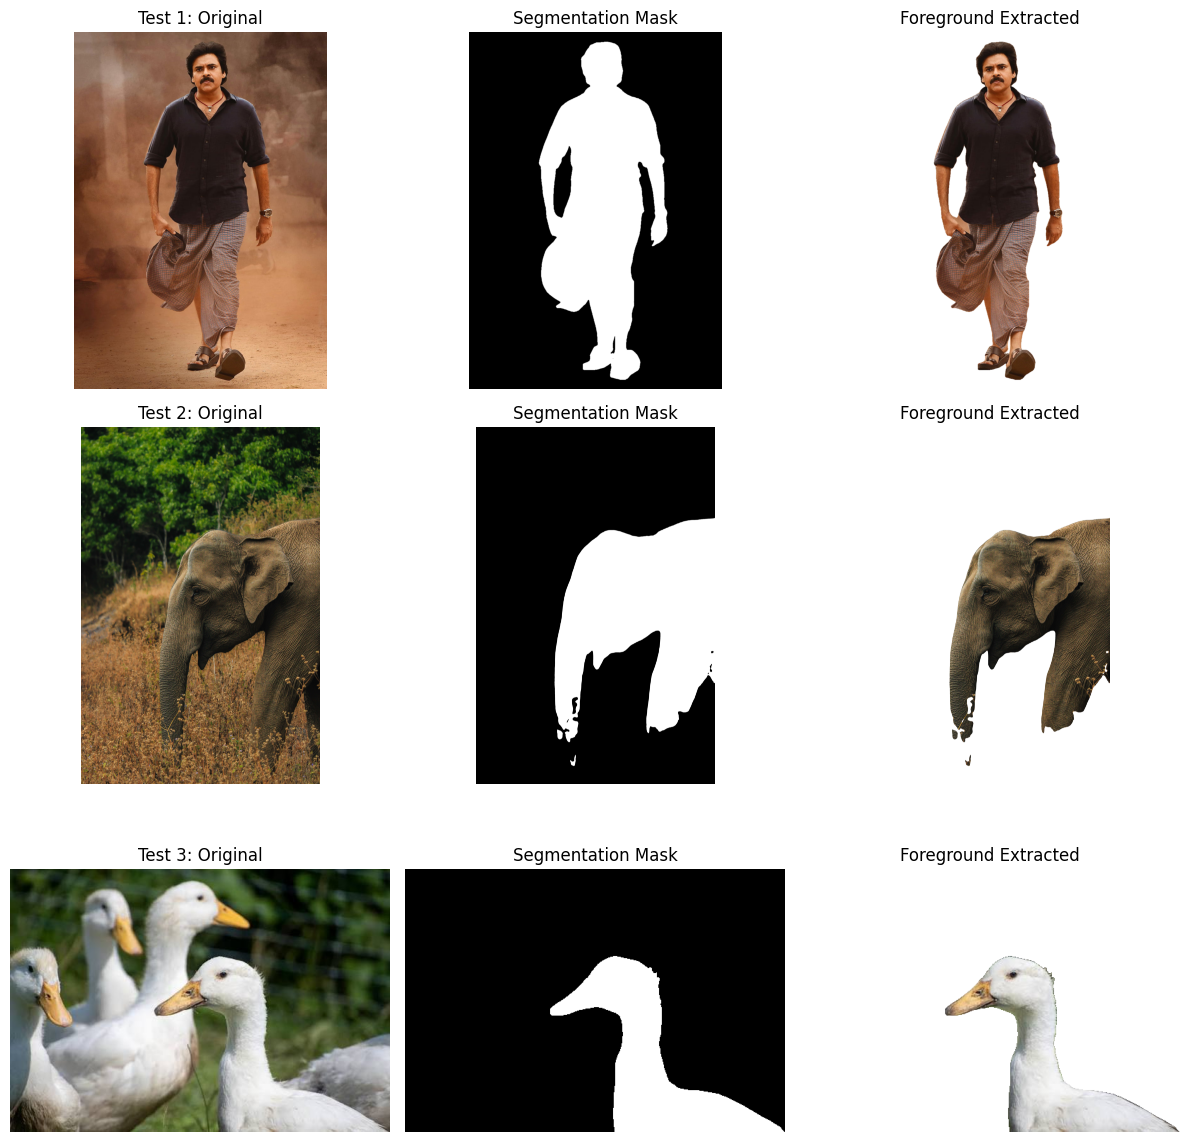

In [7]:
results = []
for path in test_image_paths:
    original, mask, foreground = segment_image(path, model_session)
    results.append((path, original, mask, foreground))
    print(f"Processed: {path}")

fig, axes = plt.subplots(len(results), 3, figsize=(12, 4 * len(results)))
for i, (path, original, mask, foreground) in enumerate(results):
    axes[i, 0].imshow(original);            axes[i, 0].set_title(f"Test {i+1}: Original"); axes[i, 0].axis("off")
    axes[i, 1].imshow(mask, cmap="gray");   axes[i, 1].set_title("Segmentation Mask");      axes[i, 1].axis("off")
    axes[i, 2].imshow(foreground);          axes[i, 2].set_title("Foreground Extracted");   axes[i, 2].axis("off")
plt.tight_layout()
plt.show()

## 9. Results / Observations
the model separates the main subject cleanly in all
3 cases; edges are sharpest where the subject contrasts clearly with the background.

## 10. Limitations
- Assumes **one main salient object**; not built for multi-object/multi-class segmentation.
- Accuracy drops on low-contrast images or fine structures (hair, glass, fur edges).
- No fine-tuning was done — it won't specialize to a very specific domain on its own.

## 11. Future Scope
- Fine-tune (transfer learning) on a domain-specific dataset.
- Combine with an object detector (e.g. YOLO) for multi-object segmentation.
- Deploy as a live webcam background-removal app.

## 12. Conclusion
This project used a pretrained U-Net-family model (U²-Net) purely for **inference** to
solve pixel-level foreground/background separation — no training from scratch. We
understood its encoder–decoder-with-skip-connections architecture, ran it on 3 test
images, post-processed the raw mask into a clean foreground cut-out, and visualized/
saved the results, demonstrating how a pretrained segmentation model becomes a
practical application.
